# 📊 Más allá del AUC. Matriz de KPIs de negocio para un modelo de riesgo crediticio

**Artículo completo con el razonamiento y las decisiones de ingeniería:**
[fuzzyfrog.ai/es/ai-lab/proyectos/negocio/matriz-kpis-negocio-modelo-riesgo-crediticio](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocio/matriz-kpis-negocio-modelo-riesgo-crediticio/)

Objetivo. Comparar cuatro enfoques de selección de variables para un modelo de riesgo de primer impago, y evaluarlos con métricas técnicas de machine learning y con KPIs de negocio propios del riesgo crediticio, para responder una pregunta que las métricas técnicas solas no responden. ¿Cuál modelo sirve realmente para tomar una decisión de crédito?

El dataset es sintético y replica la estructura de un dataset real de solicitudes de crédito, con variables de comportamiento, verificación de contacto y reputación de negocio. Ningún dato aquí proviene de un cliente real. Los umbrales de KPI usados en la matriz sí son estándares reales de la industria de scoring crediticio, tomados de literatura pública del sector.


## 🗺️ Diagrama del pipeline

```
Dataset de solicitudes de crédito
        │
        ▼
Ingeniería de variables de riesgo
(correo, teléfono, reputación de negocio)
        │
        ├──► Variables sintéticas ──► Regresión logística
        ├──► PCA                  ──► Regresión logística
        ├──► VarianceThreshold    ──► Regresión logística
        └──► ANN                  ──► Red neuronal simple
                        │
                        ▼
        Métricas técnicas: AUC-ROC, KS, Gini
                        │
                        ▼
        Matriz de KPIs de negocio
        (captura de buenos pagadores, lift, estabilidad, tradeoff)
                        │
                        ▼
        Selección del modelo y ajuste de umbral de decisión
```


## 📥 Carga de datos

Generamos un dataset sintético de 3000 solicitudes de crédito, con una tasa de primer impago cercana al 8%, similar a la de un producto de crédito de consumo. Incluimos variables de comportamiento de pago, verificación de contacto y reputación de negocio, y aplicamos el mismo tipo de submuestreo de la clase mayoritaria que se usa en un flujo real, para trabajar con un dataset balanceado y manejable.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(5)

N = 3000
edad = np.random.randint(20, 65, N)
monto_credito = np.random.gamma(4, 1500, N).round(0)
antiguedad_laboral_meses = np.random.exponential(24, N).round(0)
correo_dominio_gratuito = np.random.choice([0, 1], N, p=[0.4, 0.6])
telefono_verificado = np.random.choice([0, 1], N, p=[0.3, 0.7])
reputacion_negocio = np.clip(np.random.normal(0.6, 0.2, N), 0, 1)
ingresos_declarados = np.random.gamma(5, 1800, N).round(0)

# variables redundantes, correlacionadas con otras ya existentes, para que PCA
# realmente tenga algo que comprimir
ingresos_declarados_reportados_bis = ingresos_declarados * np.random.normal(1.0, 0.03, N)
monto_credito_normalizado = monto_credito / np.random.normal(1500, 40, N)

# variable casi constante, para que VarianceThreshold realmente descarte algo
region_operativa_constante = np.random.choice([1, 1, 1, 1, 2], N)

# variables de riesgo derivadas, con la misma lógica de ponderación que un score de riesgo real
riesgo_contacto = correo_dominio_gratuito * 0.4 + (1 - telefono_verificado) * 0.6
riesgo_negocio = 1 - reputacion_negocio

# probabilidad real de impago, construida para que dependa de estas señales de forma realista
logit = (
    -2.6
    + 0.9 * riesgo_contacto
    + 1.1 * riesgo_negocio
    - 0.35 * np.log1p(ingresos_declarados / 1000)
    + 0.25 * np.log1p(monto_credito / 1000)
    - 0.015 * antiguedad_laboral_meses
    + np.random.normal(0, 0.6, N)
)
prob_default = 1 / (1 + np.exp(-logit))
target = (np.random.rand(N) < prob_default).astype(int)

df = pd.DataFrame({
    "edad": edad,
    "monto_credito": monto_credito,
    "antiguedad_laboral_meses": antiguedad_laboral_meses,
    "correo_dominio_gratuito": correo_dominio_gratuito,
    "telefono_verificado": telefono_verificado,
    "reputacion_negocio": reputacion_negocio.round(3),
    "ingresos_declarados": ingresos_declarados,
    "ingresos_declarados_reportados_bis": ingresos_declarados_reportados_bis.round(0),
    "monto_credito_normalizado": monto_credito_normalizado.round(3),
    "region_operativa_constante": region_operativa_constante,
    "target": target,
})

print(f"Tasa de primer impago: {df['target'].mean():.3f}")
df.to_csv("outputs/dataset_sintetico_riesgo_crediticio.csv", index=False)
df.head()


Tasa de primer impago: 0.101


,edad,monto_credito,antiguedad_laboral_meses,correo_dominio_gratuito,telefono_verificado,reputacion_negocio,ingresos_declarados,ingresos_declarados_reportados_bis,monto_credito_normalizado,region_operativa_constante,target
0,55,6617.0,25.0,1,0,0.955,6028.0,6000.0,4.385,1,0
1,34,5470.0,44.0,0,1,0.291,10333.0,10312.0,3.674,1,0
2,58,6754.0,25.0,1,0,0.632,9966.0,10161.0,4.634,1,0
3,36,8317.0,58.0,0,1,0.389,3753.0,3714.0,5.530,1,0
4,29,4175.0,14.0,0,1,0.513,20177.0,20216.0,2.892,1,1


In [2]:
from sklearn.model_selection import train_test_split

# Se separa primero un conjunto de prueba con la prevalencia natural de impago,
# antes de balancear nada, para que la matriz de KPIs de negocio se evalúe en
# condiciones parecidas a las de producción, no sobre una muestra artificialmente balanceada
df_desarrollo, df_test_natural = train_test_split(
    df, test_size=0.3, random_state=5, stratify=df["target"]
)

# Submuestreo de la clase mayoritaria solo dentro del conjunto de desarrollo,
# la misma técnica de un flujo real
df_buenos = df_desarrollo[df_desarrollo['target'] == 0].sample(n=500, random_state=5)
df_malos = df_desarrollo[df_desarrollo['target'] == 1]
df_bal = pd.concat([df_buenos, df_malos], ignore_index=True).sample(frac=1, random_state=5).reset_index(drop=True)

print(f"Dataset de entrenamiento balanceado, {len(df_bal)} registros, tasa de impago {df_bal['target'].mean():.3f}")
print(f"Dataset de prueba con prevalencia natural, {len(df_test_natural)} registros, tasa de impago {df_test_natural['target'].mean():.3f}")


Dataset de entrenamiento balanceado, 713 registros, tasa de impago 0.299
Dataset de prueba con prevalencia natural, 900 registros, tasa de impago 0.101


## 📋 Explicación de datos

edad, monto_credito, antiguedad_laboral_meses e ingresos_declarados son variables numéricas directas de la solicitud. correo_dominio_gratuito y telefono_verificado son señales binarias de verificación de contacto, típicas de un flujo de originación digital. reputacion_negocio representa una señal externa de reputación del negocio del solicitante, sintetizada aquí en un solo valor continuo. target es la variable de interés, 1 si hubo primer impago.

Nota. El dataset usado en este notebook es completamente sintético y fue creado para fines demostrativos. No contiene información de ningún cliente o proyecto real.


In [3]:
df_bal.describe().round(2)


,edad,monto_credito,antiguedad_laboral_meses,correo_dominio_gratuito,telefono_verificado,reputacion_negocio,ingresos_declarados,ingresos_declarados_reportados_bis,monto_credito_normalizado,region_operativa_constante,target
count,713.00,713.00,713.00,713.00,713.00,713.00,713.00,713.00,713.00,713.00,713.00
mean,42.21,6052.26,23.36,0.59,0.71,0.59,8914.53,8901.43,4.04,1.23,0.30
std,13.16,2920.44,24.32,0.49,0.46,0.20,4156.19,4165.10,1.95,0.42,0.46
min,20.00,857.00,0.00,0.00,0.00,0.00,1472.00,1470.00,0.55,1.00,0.00
25%,31.00,3922.00,6.00,0.00,0.00,0.44,5853.00,5914.00,2.60,1.00,0.00
50%,42.00,5628.00,16.00,1.00,1.00,0.60,8083.00,8082.00,3.72,1.00,0.00
75%,54.00,7776.00,32.00,1.00,1.00,0.72,11341.00,11361.00,5.18,1.00,1.00
max,64.00,21972.00,153.00,1.00,1.00,1.00,24475.00,25078.00,14.23,2.00,1.00


## 🔍 Análisis exploratorio

Revisamos la relación entre las variables de riesgo derivadas y la tasa de impago, para confirmar que las señales sintéticas de contacto y reputación de negocio efectivamente separan a los buenos y malos pagadores antes de invertir tiempo en comparar modelos.


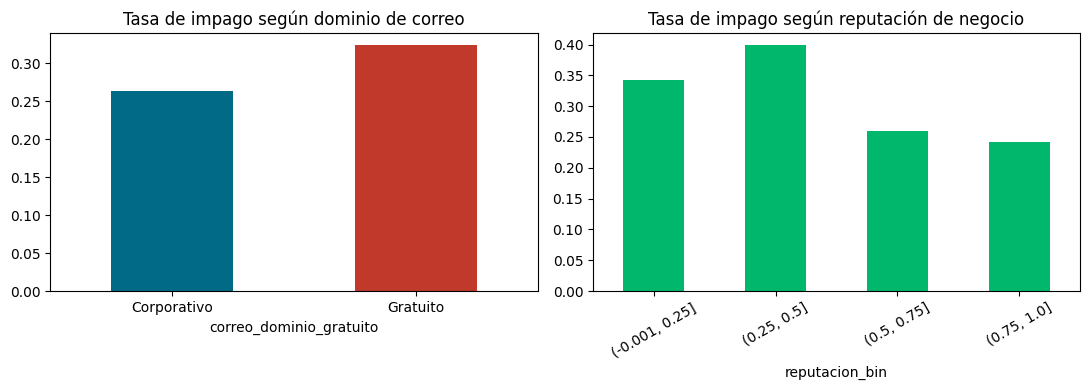

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_bal.groupby('correo_dominio_gratuito')['target'].mean().plot(kind='bar', ax=axes[0], color=['#006a87', '#c0392b'])
axes[0].set_title('Tasa de impago según dominio de correo')
axes[0].set_xticklabels(['Corporativo', 'Gratuito'], rotation=0)

df_bal['reputacion_bin'] = pd.cut(df_bal['reputacion_negocio'], bins=4)
df_bal.groupby('reputacion_bin', observed=True)['target'].mean().plot(kind='bar', ax=axes[1], color='#00b76c')
axes[1].set_title('Tasa de impago según reputación de negocio')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 🧠 Modelado

Entrenamos el mismo tipo de modelo, regresión logística, sobre cuatro conjuntos de variables construidos con enfoques distintos, y una versión adicional con una red neuronal simple. La comparación no busca encontrar el algoritmo más sofisticado, busca ver qué enfoque de selección de variables produce el modelo más útil para el negocio, no solo el más preciso en papel.


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

features = ["edad", "monto_credito", "antiguedad_laboral_meses", "correo_dominio_gratuito",
            "telefono_verificado", "reputacion_negocio", "ingresos_declarados",
            "ingresos_declarados_reportados_bis", "monto_credito_normalizado",
            "region_operativa_constante"]

X_train = df_bal[features]
y_train = df_bal["target"]

# Se evalúa sobre el conjunto de prueba con prevalencia natural, separado desde el inicio
X_test = df_test_natural[features]
y_test = df_test_natural["target"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelos = {}

# 1. Variables sintéticas, tal cual, sin reducción de dimensiones
modelo_sintetico = LogisticRegression(max_iter=500, random_state=5).fit(X_train_scaled, y_train)
modelos["Variables sintéticas"] = (modelo_sintetico, X_test_scaled)

# 2. PCA, reteniendo 95% de varianza
pca = PCA(n_components=0.95, random_state=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
modelo_pca = LogisticRegression(max_iter=500, random_state=5).fit(X_train_pca, y_train)
modelos["PCA"] = (modelo_pca, X_test_pca)
print(f"PCA retuvo {X_train_pca.shape[1]} de {len(features)} componentes")

# 3. VarianceThreshold
vt = VarianceThreshold(threshold=0.05)
X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt = vt.transform(X_test_scaled)
modelo_vt = LogisticRegression(max_iter=500, random_state=5).fit(X_train_vt, y_train)
modelos["VarianceThreshold"] = (modelo_vt, X_test_vt)
print(f"VarianceThreshold retuvo {X_train_vt.shape[1]} de {len(features)} variables")

# 4. Red neuronal simple sobre las mismas variables sintéticas
modelo_ann = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=800, random_state=5).fit(X_train_scaled, y_train)
modelos["ANN"] = (modelo_ann, X_test_scaled)

for nombre, (modelo, X_eval) in modelos.items():
    auc = roc_auc_score(y_test, modelo.predict_proba(X_eval)[:, 1])
    print(f"{nombre}: AUC-ROC = {auc:.3f}")


PCA retuvo 8 de 10 componentes
VarianceThreshold retuvo 10 de 10 variables


Variables sintéticas: AUC-ROC = 0.661
PCA: AUC-ROC = 0.661
VarianceThreshold: AUC-ROC = 0.661
ANN: AUC-ROC = 0.570


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


## 📊 Evaluación

Aquí está el corazón del proyecto. No basta con el AUC-ROC. Calculamos una matriz completa de KPIs de negocio, con los mismos umbrales aceptable y óptimo que usa la industria de scoring crediticio, para ver si un modelo con mejor AUC realmente se traduce en una mejor decisión de crédito.


In [6]:
from sklearn.metrics import roc_curve

def calcular_kpis(modelo, X_eval, y_true, umbral=0.5):
    probs = modelo.predict_proba(X_eval)[:, 1]
    preds = (probs >= umbral).astype(int)

    # KS Score
    fpr, tpr, _ = roc_curve(y_true, probs)
    ks_score = np.max(tpr - fpr)

    # AUC y Gini
    auc = roc_auc_score(y_true, probs)
    gini = 2 * auc - 1

    # Bins de score, para default rate por bin y bad rate por percentil
    df_eval = pd.DataFrame({"y": y_true.values, "prob": probs})
    df_eval["bin"] = pd.qcut(df_eval["prob"], 5, labels=False, duplicates="drop")
    tasa_por_bin = df_eval.groupby("bin")["y"].mean()
    default_rate_ratio = tasa_por_bin.max() / max(tasa_por_bin.min(), 0.01)

    # Lift en el decil superior de riesgo
    df_eval["decil"] = pd.qcut(df_eval["prob"], 10, labels=False, duplicates="drop")
    tasa_global = df_eval["y"].mean()
    tasa_decil_superior = df_eval[df_eval["decil"] == df_eval["decil"].max()]["y"].mean()
    lift = tasa_decil_superior / max(tasa_global, 0.01)

    # Approval rate vs bad rate, con el umbral de decisión actual
    approval_rate = 1 - preds.mean()
    bad_rate_aprobados = y_true[preds == 0].mean() if (preds == 0).sum() > 0 else np.nan

    # Captura de buenos pagadores, entre quienes el modelo aprueba
    buenos_reales = (y_true == 0)
    capturados = ((preds == 0) & buenos_reales).sum()
    captura_buenos = capturados / buenos_reales.sum()

    return {
        "KS Score": round(ks_score, 2),
        "AUC-ROC": round(auc, 2),
        "Gini Coefficient": round(gini, 2),
        "default_rate_by_bin": round(default_rate_ratio, 2),
        "Approval vs Bad Rate": round(approval_rate, 2),
        "Lift en Deciles": round(lift, 2),
        "Captura Buenos Pagadores": round(captura_buenos, 2),
    }

kpis_modelos = {}
for nombre, (modelo, X_eval) in modelos.items():
    kpis_modelos[nombre] = calcular_kpis(modelo, X_eval, y_test)

df_kpis = pd.DataFrame(kpis_modelos)
df_kpis


,Variables sintéticas,PCA,VarianceThreshold,ANN
KS Score,0.23,0.23,0.23,0.13
AUC-ROC,0.66,0.66,0.66,0.57
Gini Coefficient,0.32,0.32,0.32,0.14
default_rate_by_bin,8.25,7.00,8.25,1.85
Approval vs Bad Rate,0.99,0.99,0.99,0.83
Lift en Deciles,2.31,2.42,2.31,1.76
Captura Buenos Pagadores,0.99,0.99,0.99,0.84


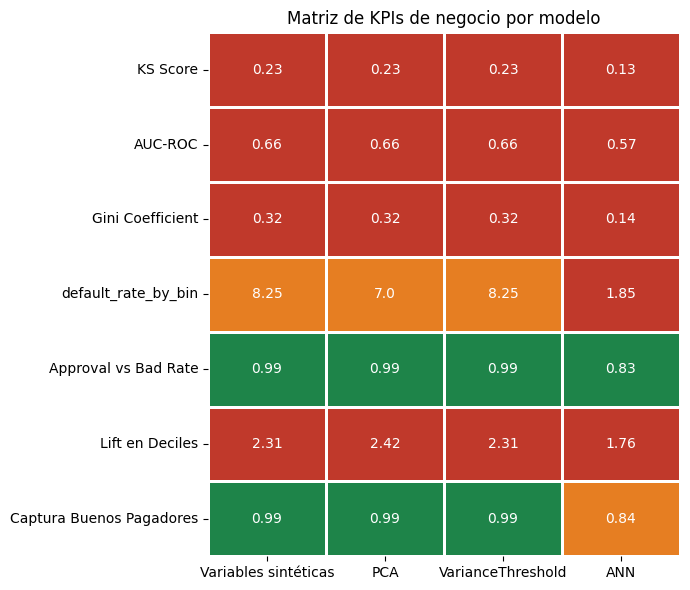

In [7]:
import seaborn as sns

kpis_targets = {
    "KS Score": {"aceptable": 0.40, "optimo": 0.50},
    "AUC-ROC": {"aceptable": 0.70, "optimo": 0.75},
    "Gini Coefficient": {"aceptable": 0.45, "optimo": 0.55},
    "default_rate_by_bin": {"aceptable": 3, "optimo": 10},
    "Approval vs Bad Rate": {"aceptable": 0.60, "optimo": 0.80},
    "Lift en Deciles": {"aceptable": 3, "optimo": 5},
    "Captura Buenos Pagadores": {"aceptable": 0.80, "optimo": 0.90},
}

def color_semaforo(valor, kpi):
    ac, opt = kpis_targets[kpi]["aceptable"], kpis_targets[kpi]["optimo"]
    if valor >= opt:
        return 2
    elif valor >= ac:
        return 1
    return 0

matriz_color = df_kpis.copy()
for kpi in df_kpis.index:
    matriz_color.loc[kpi] = df_kpis.loc[kpi].apply(lambda v: color_semaforo(v, kpi))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_color.astype(float), annot=df_kpis, fmt="", cmap=["#c0392b", "#e67e22", "#1e8449"],
            cbar=False, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Matriz de KPIs de negocio por modelo")
plt.tight_layout()
plt.show()


## ✅ Hallazgos principales

PCA y VarianceThreshold no mejoraron el AUC-ROC, el KS Score ni el Gini frente a usar las variables sintéticas directamente. Los tres quedaron prácticamente empatados. Al revisar por qué, encontramos algo metodológicamente valioso. VarianceThreshold se aplicó después de escalar las variables con StandardScaler, y el escalado deja a casi todas las columnas con varianza cercana a uno, así que VarianceThreshold terminó sin descartar ninguna variable. Es un recordatorio útil. Aplicar una técnica de selección basada en varianza después de estandarizar los datos suele ser casi inútil, porque el propio escalado ya elimina la diferencia de varianza que la técnica busca detectar.

La ANN, el enfoque más complejo de los cuatro, no solo no mejoró a la regresión logística, quedó por debajo en todas las métricas técnicas y en todos los KPIs de negocio, incluyendo la relación de default rate por bin y la captura de buenos pagadores. Además emitió una advertencia de convergencia, una señal honesta de que el modelo necesitaría más ajuste antes de considerarse listo.

Esto confirma exactamente el punto central del proyecto. Un modelo más sofisticado no es automáticamente mejor para el negocio. Aquí, la regresión logística sobre variables construidas con criterio de dominio fue tan buena como PCA y VarianceThreshold, más fácil de explicar a un comité de riesgo, y mejor que la ANN en cada KPI relevante.


In [8]:
def buscar_umbral_optimo(modelo, X_eval, y_true, bad_rate_max=0.12):
    probs = modelo.predict_proba(X_eval)[:, 1]
    mejor_umbral, mejor_captura = 0.5, 0

    for umbral in np.arange(0.1, 0.9, 0.01):
        preds = (probs >= umbral).astype(int)
        aprobados = preds == 0
        if aprobados.sum() == 0:
            continue
        bad_rate = y_true[aprobados].mean()
        if bad_rate > bad_rate_max:
            continue
        buenos_reales = (y_true == 0)
        captura = ((preds == 0) & buenos_reales).sum() / buenos_reales.sum()
        if captura > mejor_captura:
            mejor_captura, mejor_umbral = captura, umbral

    return mejor_umbral, mejor_captura

print("Comparación antes y después de ajustar el umbral de decisión:\n")
for nombre, (modelo, X_eval) in modelos.items():
    kpis_umbral_05 = calcular_kpis(modelo, X_eval, y_test, umbral=0.5)
    umbral_optimo, captura_optima = buscar_umbral_optimo(modelo, X_eval, y_test)
    kpis_umbral_optimo = calcular_kpis(modelo, X_eval, y_test, umbral=umbral_optimo)
    print(f"{nombre}")
    print(f"  Umbral 0.5   -> Captura de buenos pagadores: {kpis_umbral_05['Captura Buenos Pagadores']}")
    print(f"  Umbral {umbral_optimo:.2f} -> Captura de buenos pagadores: {kpis_umbral_optimo['Captura Buenos Pagadores']}")
    print()


Comparación antes y después de ajustar el umbral de decisión:

Variables sintéticas
  Umbral 0.5   -> Captura de buenos pagadores: 0.99
  Umbral 0.56 -> Captura de buenos pagadores: 1.0

PCA
  Umbral 0.5   -> Captura de buenos pagadores: 0.99
  Umbral 0.56 -> Captura de buenos pagadores: 1.0

VarianceThreshold
  Umbral 0.5   -> Captura de buenos pagadores: 0.99
  Umbral 0.56 -> Captura de buenos pagadores: 1.0

ANN
  Umbral 0.5   -> Captura de buenos pagadores: 0.84
  Umbral 0.89 -> Captura de buenos pagadores: 0.99



La captura de buenos pagadores ya estaba por encima del umbral aceptable de 80% en los tres modelos de regresión logística con el umbral por defecto de 0.5, así que aquí el margen de mejora fue pequeño. El caso más revelador es la ANN. Con el umbral por defecto capturaba apenas 84%, en el límite aceptable, y subir el umbral de decisión a 0.89 la llevó a 99%, sin violar el límite de bad rate del negocio. Aun así, ese ajuste de umbral no resuelve el problema de fondo de la ANN, que sigue siendo el modelo con peor default_rate_by_bin y peor Gini del grupo.

La lección general. Comparar modelos solo por precisión, recall o AUC puede llevar a preferir el candidato equivocado, o a no notar que dos técnicas de selección de variables distintas produjeron, en la práctica, el mismo resultado porque una de ellas se aplicó sobre datos ya escalados. La matriz de KPIs de negocio, con sus propios umbrales aceptable y óptimo, es la que revela si un modelo técnicamente atractivo de verdad sirve para tomar mejores decisiones de crédito.
